B.1. Write Python code to implement a regression model for weather forecasting.
Compare simple regression, Ridge regression, and Lasso regression.

Simple linear regration consists of main 3 functions: 
1. main regration function for prediction
    $
    y = mx + b
    $

2. Error Function 
$E = \frac{1}{m}\sum_{i=0}^{n}{(yi - (mx + b))^2}$

our main goal is to find $\textbf{m}$ and $\textbf{b}$ where the $\textbf{E}$ is minimum

so for the minimum of $\textbf{E}$ 

1. $\frac{\delta{E}}{\delta{m}} = -\frac{2}{n}\sum_{i=0}^{n}{x(yi - (mx + b))}$

2. $\frac{\delta{E}}{\delta{b}} = -\frac{2}{n}\sum_{i=0}^{n}{(yi - {mx + b})}$

$\textbf{simple regression}$

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [33]:
weather_data = pd.read_csv('/home/rito/ju_class/Diptadip/weather.csv')
weather_df = pd.DataFrame(weather_data)
print(weather_df)

     MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine WindGustDir  \
0        8.0     24.3       0.0          3.4       6.3          NW   
1       14.0     26.9       3.6          4.4       9.7         ENE   
2       13.7     23.4       3.6          5.8       3.3          NW   
3       13.3     15.5      39.8          7.2       9.1          NW   
4        7.6     16.1       2.8          5.6      10.6         SSE   
..       ...      ...       ...          ...       ...         ...   
361      9.0     30.7       0.0          7.6      12.1         NNW   
362      7.1     28.4       0.0         11.6      12.7           N   
363     12.5     19.9       0.0          8.4       5.3         ESE   
364     12.5     26.9       0.0          5.0       7.1          NW   
365     12.3     30.2       0.0          6.0      12.6          NW   

     WindGustSpeed WindDir9am WindDir3pm  WindSpeed9am  ...  Humidity3pm  \
0             30.0         SW         NW           6.0  ...           29   
1      

In [34]:
# Convert to numpy arrays (optional but good practice)
x_data = np.array(weather_df.Evaporation)
y_data = np.array(weather_df.MaxTemp)

# Create random indices for training (2/3 of data)
train_indices = np.random.choice(len(x_data), int(2 * len(x_data) / 3), replace=False)

# Remaining indices for testing
test_indices = np.setdiff1d(np.arange(len(x_data)), train_indices)

# Split data
x_train = x_data[train_indices]
y_train = y_data[train_indices]

x_test = x_data[test_indices]
y_test = y_data[test_indices]


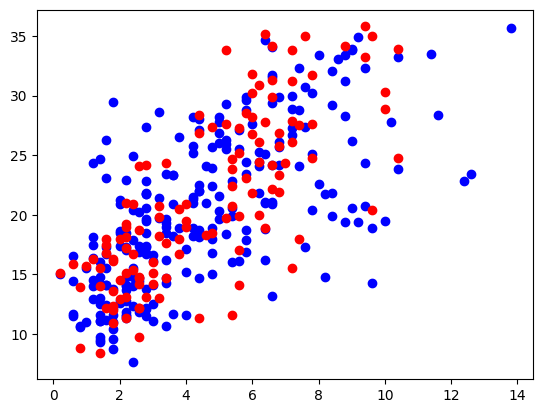

In [35]:
plt.scatter(x_train,y_train,color="blue")
plt.scatter(x_test,y_test,color='red')
plt.show()

In [36]:
#error function
def errror_func(m,b,x,y):
    total_error = 0
    for i in range(len(x)):
        total_error += (y - (m*x + b))**2
    total_error / float(len(x))
    return total_error

In [37]:
def gradient_decent(m_now, b_now, x, y, L):
    m_grad = 0
    b_grad = 0

    n = len(x)

    for i in range(n):
        m_grad += -(2/n)*(y[i] - (m_now*x[i] + b_now)) * x[i]
        b_grad += -(2/n)*(y[i] - (m_now*x[i] + b_now))

    m_l = m_now - L * m_grad
    b_l = b_now - L * b_grad
    
    return (m_l,b_l)

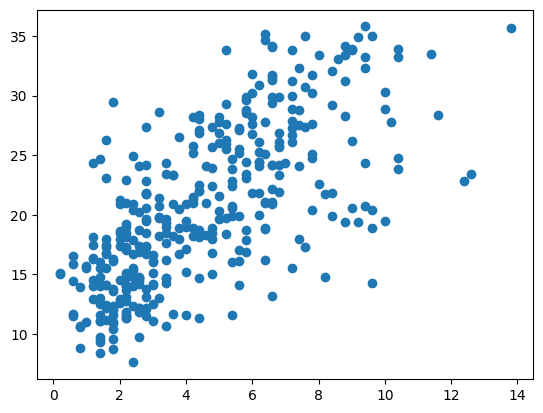

In [38]:
plt.scatter(x_data,y_data)
plt.show()

Epoches: 0
Epoches: 50
Epoches: 100
Epoches: 150
Epoches: 200
Epoches: 250
Epoches: 300
Epoches: 350
Epoches: 400
Epoches: 450
Epoches: 500
Epoches: 550
Epoches: 600
Epoches: 650
Epoches: 700
Epoches: 750
Epoches: 800
Epoches: 850
Epoches: 900
Epoches: 950
Epoches: 1000
Epoches: 1050
Epoches: 1100
Epoches: 1150
Epoches: 1200
Epoches: 1250
Epoches: 1300
Epoches: 1350
Epoches: 1400
Epoches: 1450
Epoches: 1500
Epoches: 1550
Epoches: 1600
Epoches: 1650
Epoches: 1700
Epoches: 1750
Epoches: 1800
Epoches: 1850
Epoches: 1900
Epoches: 1950
Epoches: 2000
Epoches: 2050
Epoches: 2100
Epoches: 2150
Epoches: 2200
Epoches: 2250
Epoches: 2300
Epoches: 2350
Epoches: 2400
Epoches: 2450
Epoches: 2500
Epoches: 2550
Epoches: 2600
Epoches: 2650
Epoches: 2700
Epoches: 2750
Epoches: 2800
Epoches: 2850
Epoches: 2900
Epoches: 2950
Epoches: 3000
Epoches: 3050
Epoches: 3100
Epoches: 3150
Epoches: 3200
Epoches: 3250
Epoches: 3300
Epoches: 3350
Epoches: 3400
Epoches: 3450
Epoches: 3500
Epoches: 3550
Epoches: 3600
E

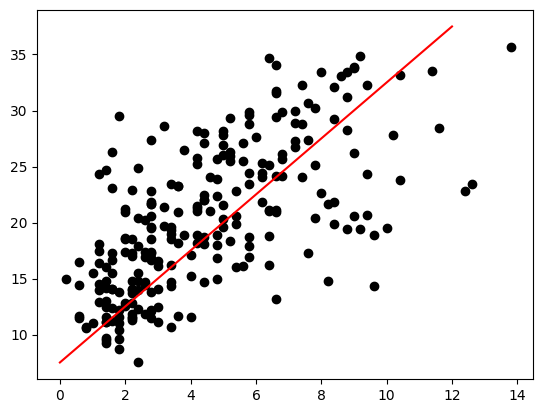

In [61]:
m = 0 
b = 0

#have to play with the values below to best results and mostly L as the gradient decent depends on L
L = 0.0003
epochs = 5000

for i in range(epochs):
    if i % 50 == 0:
        print(f"Epoches: {i}")
    m, b  = gradient_decent(m,b,x_train,y_train,L)

print(m,b)

plt.scatter(x_train,y_train, color="black")
plt.plot(list(range(int(min(x_data)),int(max(x_data)))),[m*x + b for x in range(int(min(x_data)),int(max(x_data)))], color = "red")
plt.show()

$\textbf{Validation of regration}$

In [ ]:
import numpy as np

y_true = np.array(y_test)
y_pred = m * x_test + b

rms = np.sqrt(np.mean((y_pred - y_true) ** 2))
relative_rms = rms / np.mean(y_true) * 100

print(f"RMSE: {rms}")
print(f"Relative RMSE (%): {relative_rms:.2f}%")


RMSE: 5.102603531275851
Relative RMSE (%): 24.13%


$\textbf{Ridge regression}$